In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
from scipy.io import wavfile

# config

In [ ]:

SPB = 128        
FS = 3200        
FREQS = np.array([100, 200, 300, 400, 500, 600])

t_bit = np.linspace(0, SPB / FS, SPB, endpoint=False)
lo_dict = {f: np.sqrt(2/SPB) * np.cos(2 * np.pi * f * t_bit) for f in FREQS}



#  UTILS 

In [ ]:

def text_to_bits(text):
    return[int(b) for b in ''.join(format(ord(c), '08b') for c in text)]

def bits_to_text(bits):
    out =[]
    for i in range(0, len(bits), 8):
        byte = bits[i:i+8]
        if len(byte) < 8:
            break
        val = int(''.join(map(str, byte)), 2)
        out.append(chr(val) if 32 <= val <= 126 else '.')
    return ''.join(out)

#  TRANSMITTER (BPSK + FHSS) 


In [5]:


def tx(bits):
    n = len(bits)
    symbols = np.array([1 if b == 1 else -1 for b in bits])
    signal = np.zeros(n * SPB)

    hops = np.random.randint(0, len(FREQS), n)

    for i in range(n):
        start = i * SPB
        end = start + SPB
        f = FREQS[hops[i]]
        signal[start:end] = symbols[i] * lo_dict[f]

    return signal, hops


#  CHANNEL Noise + Jammer


In [ ]:


def channel(sig, snr_db=10, jammer_f=None, jammer_power_db=3):
    snr_lin = 10**(snr_db / 10)
    noise_power = 1 / (2 * snr_lin) 
    noise = np.random.normal(0, np.sqrt(noise_power), len(sig))

    out = sig + noise

    # Jammer
    if jammer_f is not None:
        t = np.arange(len(sig)) / FS
        
        p_sig = 1 / SPB 
        jammer_power = p_sig * 10**(jammer_power_db / 10)

        phase = np.random.uniform(0, 2 * np.pi)
        jammer = np.sqrt(2 * jammer_power) * np.cos(2 * np.pi * jammer_f * t + phase)
        out += jammer

    return out

#  RECEIVER (Correlator) 


In [ ]:



def rx(sig, hops):
    bits_out =[]
    for i in range(len(hops)):
        start = i * SPB
        end = start + SPB
        f = FREQS[hops[i]]

        val = np.sum(sig[start:end] * lo_dict[f])
        bits_out.append(1 if val > 0 else 0)

    return bits_out

#  BER TEST 


In [ ]:

def test_ber():
    snrs = np.linspace(-4, 10, 8)
    ber =[]

    bits = np.random.randint(0, 2, 20000).tolist()
    sig, hops = tx(bits)

    for s in snrs:
        noisy = channel(sig, snr_db=s)
        rec = rx(noisy, hops)

        errors = np.sum(np.array(bits) != np.array(rec))
        b = errors / len(bits)

        ber.append(max(b, 1e-5)) 
        print(f"SNR {s:>4.1f} dB → BER {b:.6f}")

    snr_lin = 10**(snrs / 10)
    theory = 0.5 * erfc(np.sqrt(snr_lin))

    return snrs, ber, theory


#  PLOTS 


In [ ]:

def plot_all(rx_sig, snrs, ber, theory):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    ax1.specgram(rx_sig, Fs=FS, NFFT=128, noverlap=0, cmap='plasma')
    ax1.set_title("FHSS Signal + Jammer Spectrogram")
    ax1.set_ylabel("Frequency (Hz)")
    ax1.set_xlabel("Time (s)")

    # BER
    ax2.semilogy(snrs, theory, '--', label='Theoretical BPSK')
    ax2.semilogy(snrs, ber, 'o-', label='Simulation')
    ax2.set_title("Bit Error Rate (BER) vs SNR")
    ax2.set_xlabel("SNR (Eb/N0) [dB]")
    ax2.set_ylabel("BER")
    ax2.set_ylim(1e-5, 1)
    ax2.grid(True, which="both", ls="--")
    ax2.legend()

    plt.tight_layout()
    plt.show()


#  MAIN 



 Saved audio to 'fhss_radio_sound.wav'

 =-=-=-=-= FHSS Channel Test =-=-=-=-=
Original: Roger that!?
Decoded : Roger that!?

Total bit errors: 0 out of 96
Errors on jammed frequency (300 Hz): 0 out of 20 bits
Errors on safe frequencies: 0 out of 76 bits

Calculating BER (This is much faster now)...
SNR -4.0 dB → BER 0.184650
SNR -2.0 dB → BER 0.129900
SNR  0.0 dB → BER 0.078300
SNR  2.0 dB → BER 0.034450
SNR  4.0 dB → BER 0.012350
SNR  6.0 dB → BER 0.002000
SNR  8.0 dB → BER 0.000250
SNR 10.0 dB → BER 0.000000


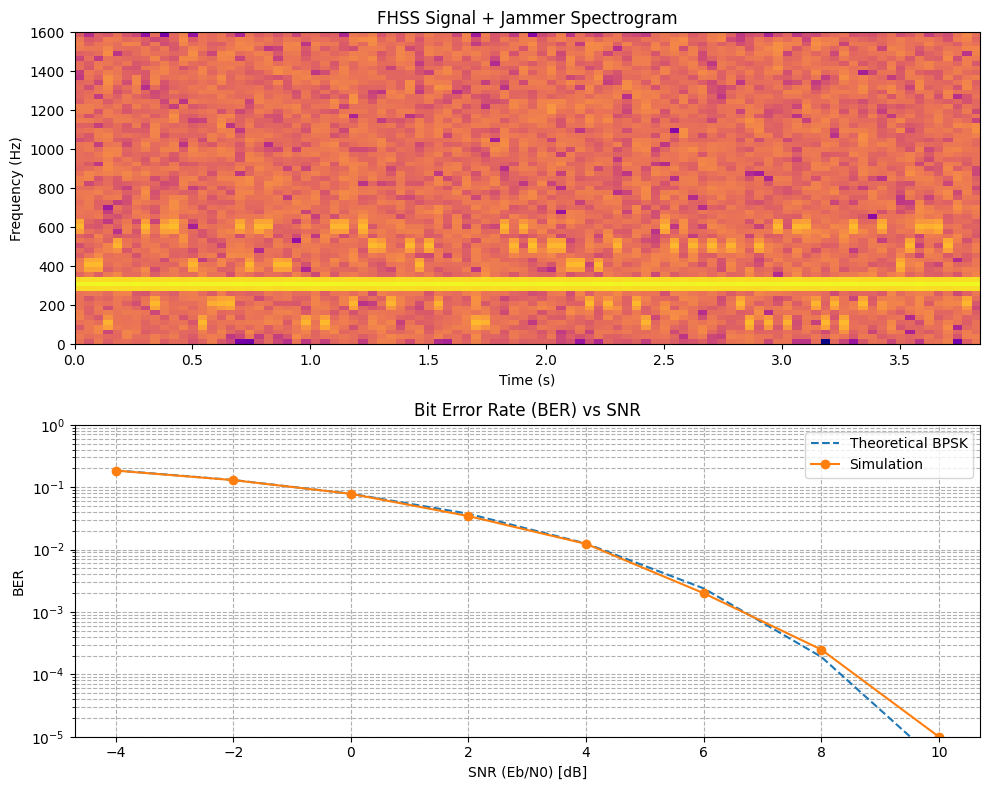

In [ ]:

def main():
    msg = "Roger that!?"
    bits = text_to_bits(msg)

    sig, hops = tx(bits)

    jammer_f = 300
    rx_sig = channel(sig, snr_db=20, jammer_f=jammer_f, jammer_power_db=15)
    out_bits = rx(rx_sig, hops)

    max_vol = np.max(np.abs(rx_sig))
    audio_data = np.int16((rx_sig / max_vol) * 32767)
    
    wavfile.write("fhss_radio_sound.wav", FS, audio_data)
    print("\n Saved audio to 'fhss_radio_sound.wav'")


    print("\n =-=-=-=-= FHSS Channel Test =-=-=-=-=")
    print("Original:", msg)
    print("Decoded :", bits_to_text(out_bits))

    errors = np.sum(np.array(bits) != np.array(out_bits))
    print(f"\nTotal bit errors: {errors} out of {len(bits)}")
    
    jammed_indices = [i for i, h in enumerate(hops) if FREQS[h] == jammer_f]
    jammed_errors = sum(1 for i in jammed_indices if bits[i] != out_bits[i])
    safe_errors = errors - jammed_errors
    
    print(f"Errors on jammed frequency ({jammer_f} Hz): {jammed_errors} out of {len(jammed_indices)} bits")
    print(f"Errors on safe frequencies: {safe_errors} out of {len(bits) - len(jammed_indices)} bits")


    snrs, ber, theory = test_ber()
    plot_all(rx_sig, snrs, ber, theory)

if __name__ == "__main__":
    main()